# Standalone MPD analysis

Plots MPD CSV data and optional PD pulse data without acoustic-emission inputs.

Set LINE_CHARGE_SCALE and PD_CHARGE_SCALE to log or linear. In log line mode, bounds expand to powers of ten. PNG files save in mpd_imgs beside the CSV.

In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LogNorm

# Global plot appearance controls
BASE_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
SUBTITLE_FONT_SIZE = 18
TICK_FONT_SIZE = 14
TICK_LENGTH = 7
TICK_WIDTH = 1.5
MINOR_TICK_LENGTH = 4
MINOR_TICK_WIDTH = 1.0
AXIS_LINE_WIDTH = 1.2

# Apparent-charge y-axis modes: choose either 'log' or 'linear'
LINE_CHARGE_SCALE = 'log'
PD_CHARGE_SCALE = 'log'

# Electrical PD event detection settings (apparent-charge trend in pC)
PD_EVENT_THRESHOLD_PC = 15
PD_EVENT_OPERATOR = '>='
PD_EVENT_N_HITS = 5
PD_EVENT_INCEPTION_WINDOW_S = 3.0
PD_EVENT_EXTINCTION_WINDOW_S = 1.0
ANNOTATE_PD_EVENTS = True

plt.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300, 'font.size': BASE_FONT_SIZE,
    'axes.titlesize': TITLE_FONT_SIZE, 'axes.labelsize': BASE_FONT_SIZE,
    'xtick.labelsize': TICK_FONT_SIZE, 'ytick.labelsize': TICK_FONT_SIZE,
    'figure.titlesize': TITLE_FONT_SIZE,
    'xtick.major.size': TICK_LENGTH, 'ytick.major.size': TICK_LENGTH,
    'xtick.major.width': TICK_WIDTH, 'ytick.major.width': TICK_WIDTH,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'xtick.minor.size': MINOR_TICK_LENGTH, 'ytick.minor.size': MINOR_TICK_LENGTH,
    'xtick.minor.width': MINOR_TICK_WIDTH, 'ytick.minor.width': MINOR_TICK_WIDTH,
    'xtick.direction': 'out', 'ytick.direction': 'out',
    'axes.linewidth': AXIS_LINE_WIDTH,
})

In [6]:
while True:
    csv_path = Path(input('MPD export CSV filepath: ').strip().strip(chr(34)))
    if csv_path.is_file():
        break
    print('File not found. Please enter a valid CSV filepath.')

pd_text = input('Optional .PD filepath (blank or None to skip): ').strip().strip(chr(34))
pd_path = None if not pd_text or pd_text.lower() == 'none' else Path(pd_text)
if pd_path and not pd_path.is_file():
    raise FileNotFoundError(f'.PD file not found: {pd_path}')
print('CSV:', csv_path)
print('.PD:', pd_path if pd_path else 'not supplied')

CSV: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_117\PD-acoustic-EMPIRE-2026-08-11_12h10m57s.csv
.PD: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_117\20260811_12h17m15s\MPD 800 1.1.1-20260811_12h10m57s206ms.PD


In [7]:
TIME_COLUMN = 'Time [s]'
VOLTAGE_COLUMN = 'AC Input RMS Voltage [V]'
CHARGE_COLUMN_C = 'IEC 60270 Apparent Charge (Q_IEC/WTD) [C]'
CHARGE_COLUMN_PC = 'IEC 60270 Apparent Charge (Q_IEC/WTD) [pC]'

def load_mpd_csv(path):
    frame = pd.read_csv(path, sep=';', skiprows=1)
    missing = {TIME_COLUMN, VOLTAGE_COLUMN, CHARGE_COLUMN_C} - set(frame.columns)
    if missing:
        raise ValueError('CSV is missing required column(s): ' + ', '.join(sorted(missing)))
    for column in (TIME_COLUMN, VOLTAGE_COLUMN, CHARGE_COLUMN_C):
        frame[column] = pd.to_numeric(frame[column], errors='coerce')
    frame = frame.dropna(subset=[TIME_COLUMN, VOLTAGE_COLUMN, CHARGE_COLUMN_C]).copy()
    frame[CHARGE_COLUMN_PC] = frame[CHARGE_COLUMN_C] * 1e12
    return frame.sort_values(TIME_COLUMN)

def load_pd_file(path):
    raw = path.read_bytes()
    count = len(raw) // 12
    if count == 0:
        raise ValueError(f'.PD file contains no complete 12-byte records: {path}')
    if len(raw) % 12:
        print(f'Warning: ignoring {len(raw) % 12} trailing byte(s) in {path.name}.')
    records = np.frombuffer(raw[:count * 12], dtype=np.uint8).reshape(count, 12)
    return records[:, 4:].copy().view('<f8').ravel(), records[:, :4].copy().view('<f4').ravel() * 1e12

mpd_df = load_mpd_csv(csv_path)
pd_time_s, pd_charge_pc = load_pd_file(pd_path) if pd_path else (None, None)
print(f'Loaded {len(mpd_df):,} CSV row(s).')
if pd_path:
    print(f'Loaded {len(pd_time_s):,} .PD pulse(s); charge converted to pC.')

Loaded 134 CSV row(s).
Loaded 6,375,157 .PD pulse(s); charge converted to pC.


,inception time [s],extinction time [s],inception voltage [V]
0,24.0,37.5,4161.022127


Saved: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_117\pd_inception_data_PD-acoustic-EMPIRE-2026-08-11_12h10m57s.csv
Saved: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_117\mpd_imgs\mpd_line_PD-acoustic-EMPIRE-2026-08-11_12h10m57s.png


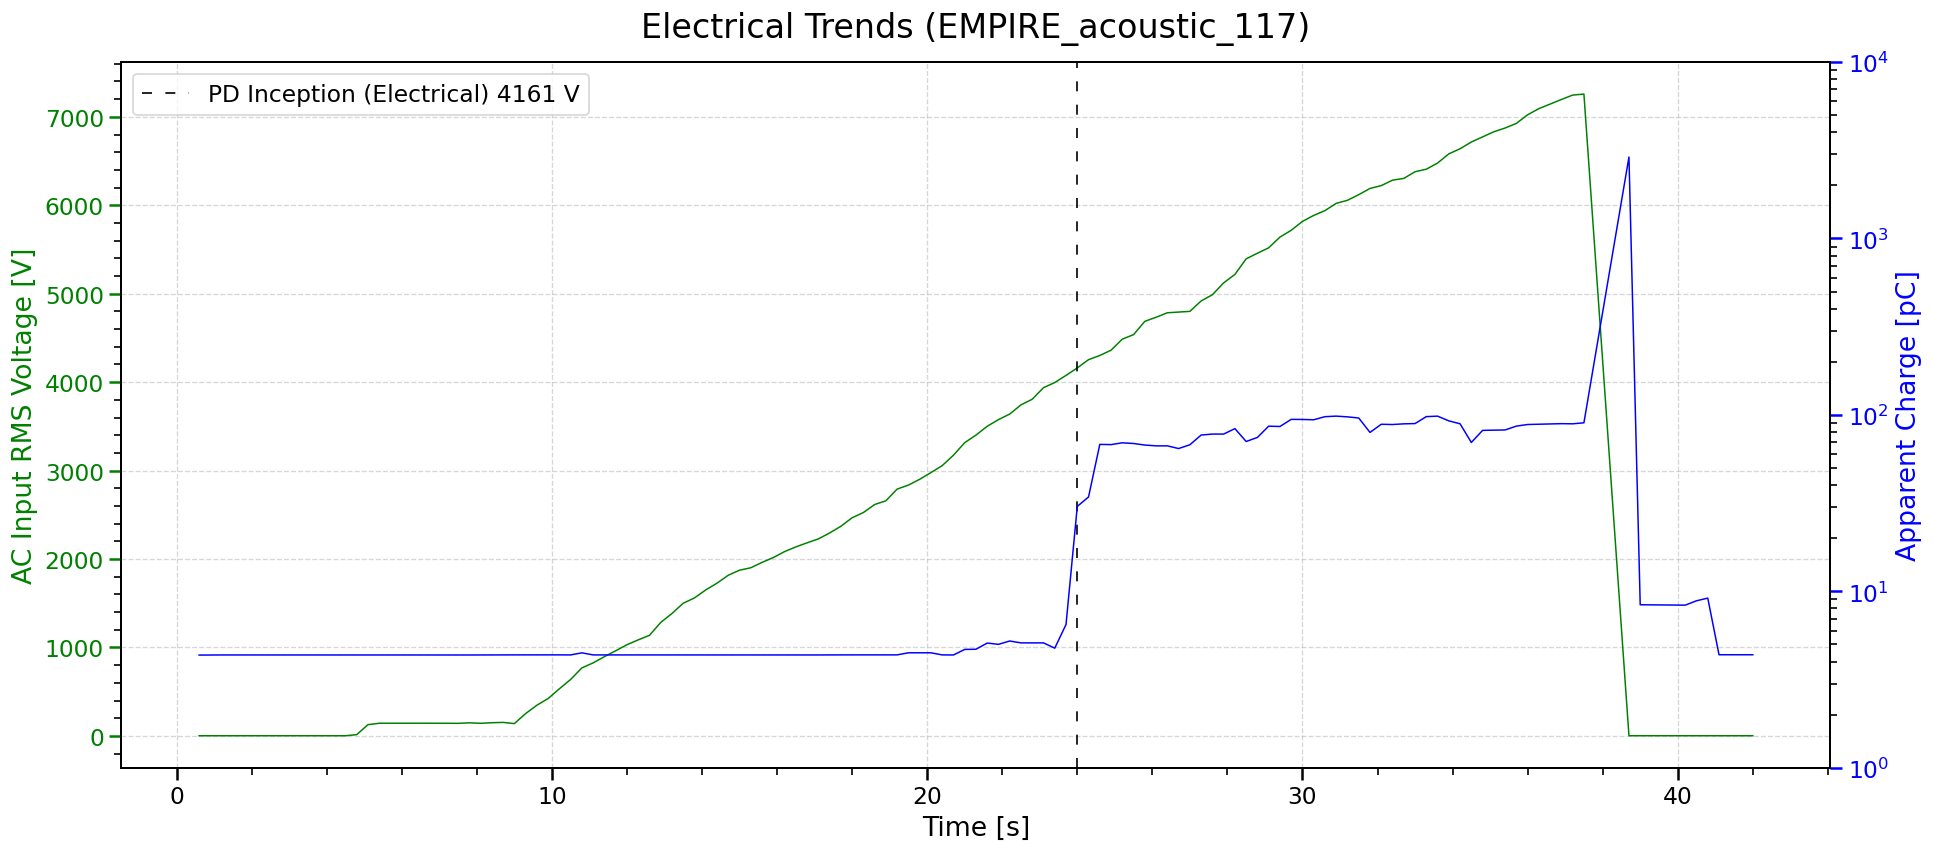

Saved: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_117\mpd_imgs\mpd_pd_hexbin_PD-acoustic-EMPIRE-2026-08-11_12h10m57s.png


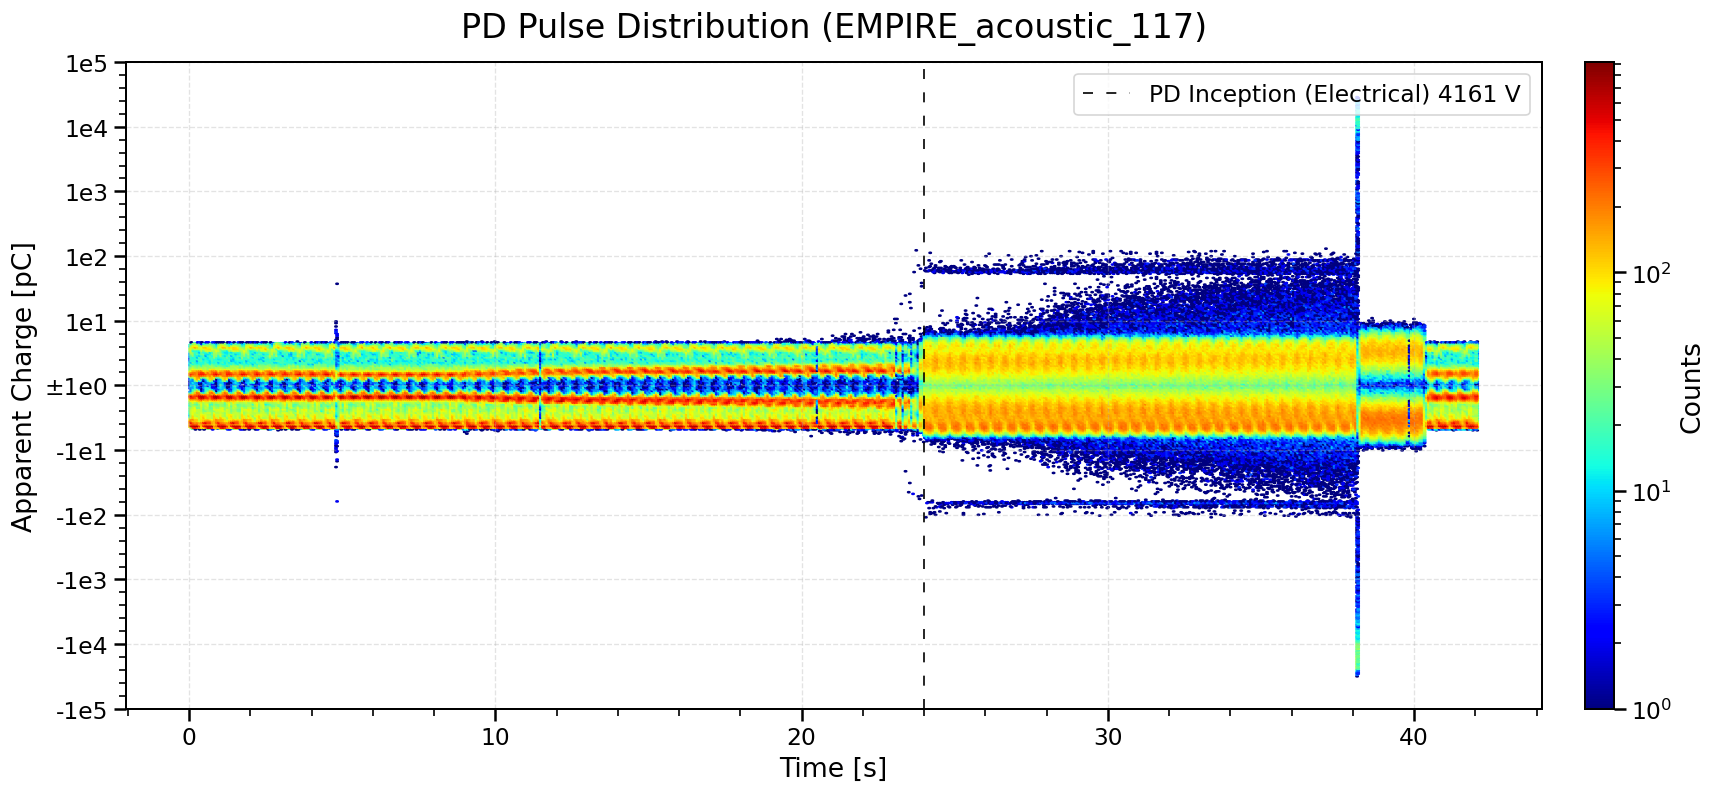

Saved: C:\Users\sapierso\OneDrive - University of Arkansas\Han Hu's files - 0_NED3_Share\0_PFI\EMPIRE_acoustic_tests\EMPIRE_acoustic_117\mpd_imgs\mpd_analysis_PD-acoustic-EMPIRE-2026-08-11_12h10m57s.png


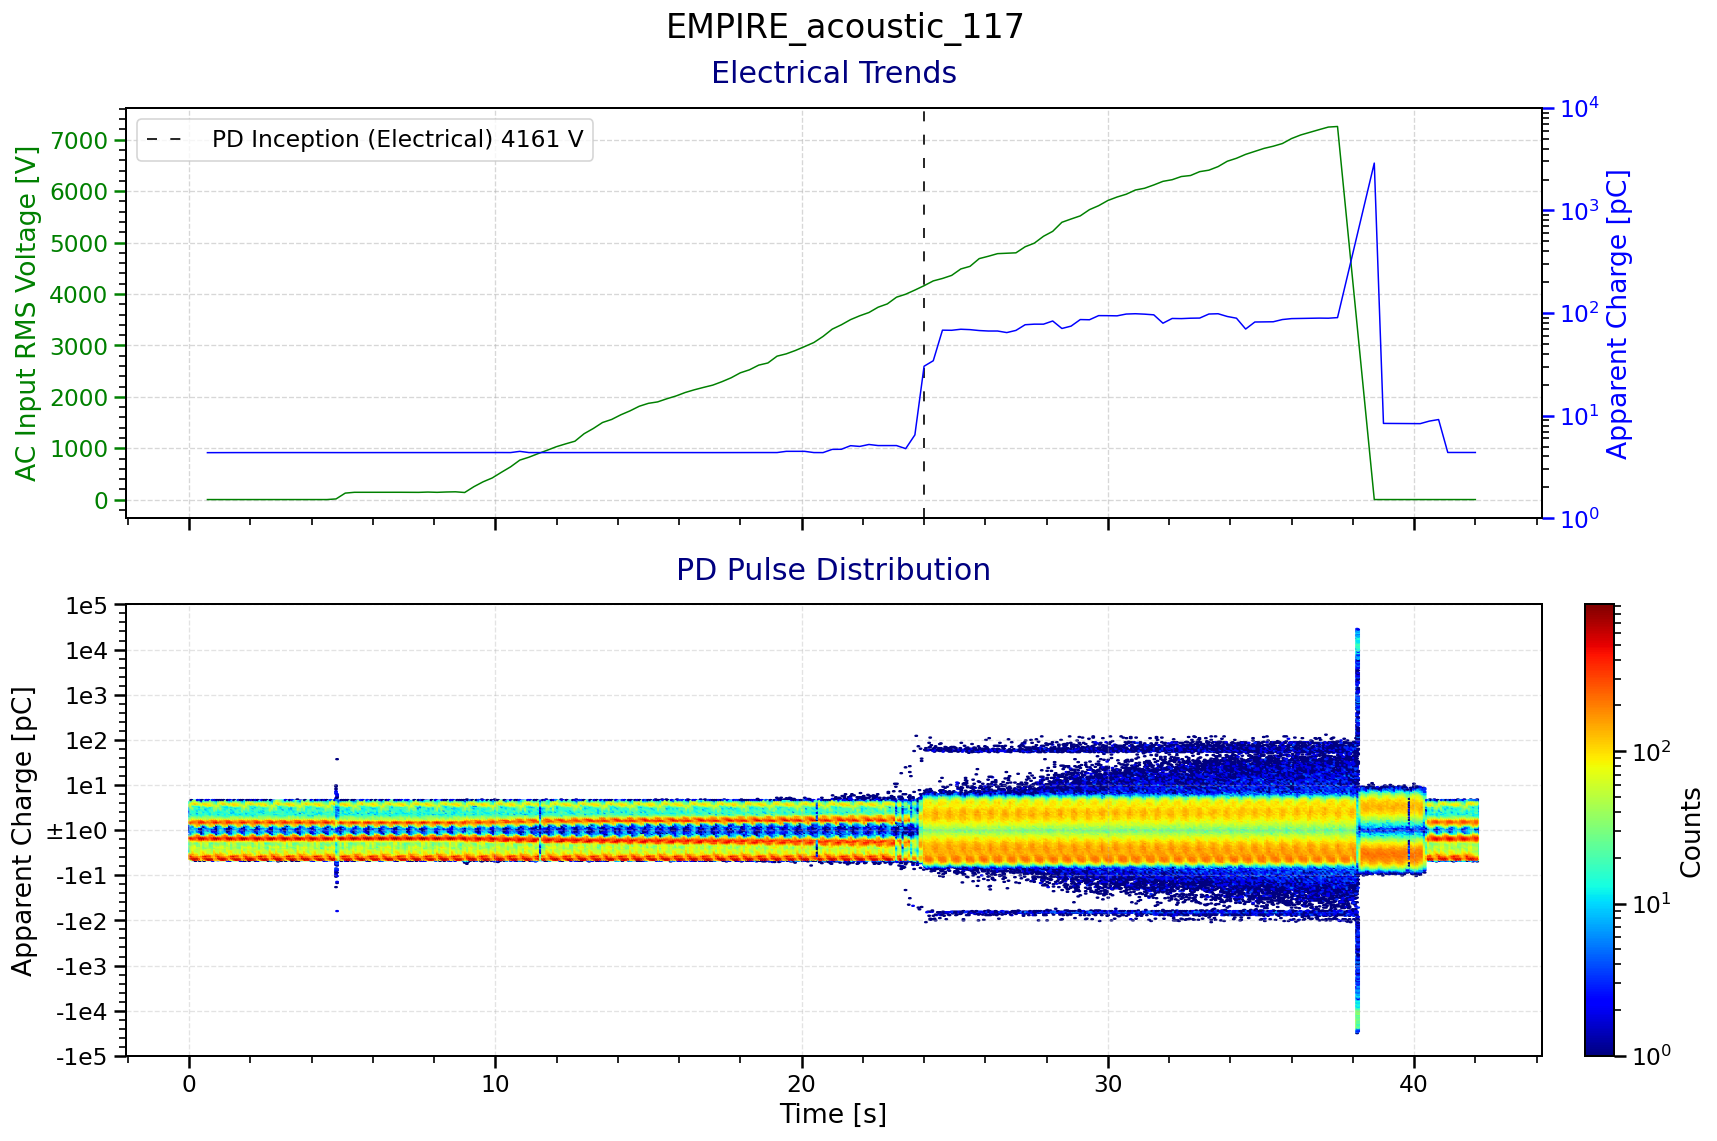

In [8]:
def validate_charge_scale(charge_scale):
    if charge_scale not in {'log', 'linear'}:
        raise ValueError("charge_scale must be either 'log' or 'linear'.")

def get_PD_times(times, param, threshold, operator='>=', n_hits=5, inception_window=3.0, extinction_window=3.0):
    """Return (inception, extinction) pairs using the EasyAE trend method."""
    if times.shape != param.shape:
        raise ValueError('times and param must have the same shape.')
    operators = {
        '>=': np.greater_equal, '<=': np.less_equal,
        '>': np.greater, '<': np.less,
    }
    if operator not in operators:
        raise ValueError("operator must be one of '>=', '<=', '>', or '<'.")
    hit_times = np.asarray(times)[operators[operator](param, threshold)]
    if hit_times.size == 0:
        return []
    pd_times, last_t_extinction = [], -np.inf
    for idx, t0 in enumerate(hit_times):
        if t0 < last_t_extinction:
            continue
        prev_count = np.sum((hit_times > t0 - extinction_window) & (hit_times < t0))
        next_count = np.sum((hit_times > t0) & (hit_times <= t0 + inception_window))
        if prev_count <= n_hits and next_count >= n_hits:
            t_ext = next((
                t1 for t1 in hit_times[idx + 1:]
                if np.sum((hit_times < t1 + extinction_window) & (hit_times > t1)) == 0
            ), hit_times[-1])
            last_t_extinction = t_ext
            pd_times.append((t0, t_ext))
    return pd_times

def find_pd_events(mpd_df, threshold=PD_EVENT_THRESHOLD_PC, operator=PD_EVENT_OPERATOR,
                   n_hits=PD_EVENT_N_HITS, inception_window=PD_EVENT_INCEPTION_WINDOW_S,
                   extinction_window=PD_EVENT_EXTINCTION_WINDOW_S):
    times = mpd_df[TIME_COLUMN].to_numpy()
    charge_pc = mpd_df[CHARGE_COLUMN_PC].to_numpy()
    event_times = get_PD_times(times, charge_pc, threshold, operator, n_hits, inception_window, extinction_window)
    return pd.DataFrame({
        'inception time [s]': [t0 for t0, _ in event_times],
        'extinction time [s]': [t_ext for _, t_ext in event_times],
        'inception voltage [V]': [np.interp(t0, times, mpd_df[VOLTAGE_COLUMN]) for t0, _ in event_times],
    })

def annotate_pd_events(ax, events):
    for index, event in events.iterrows():
        ax.axvline(event['inception time [s]'], color='black', linestyle=(0, (6, 8)), linewidth=1.0,
                   label=f"PD Inception (Electrical) {event['inception voltage [V]']:.0f} V")
    if not events.empty:
        ax.legend(loc='best', fontsize=TICK_FONT_SIZE)

def signed_log_hexbin(ax, time_s, charge_pc, charge_scale='log', gridsize=600):
    validate_charge_scale(charge_scale)
    valid = np.isfinite(time_s) & np.isfinite(charge_pc)
    if charge_scale == 'log':
        valid &= charge_pc != 0
    if not np.any(valid):
        raise ValueError('The .PD file has no finite charge values for the selected axis mode.')
    x, y_pc = time_s[valid], charge_pc[valid]
    if charge_scale == 'log':
        log_abs = np.log10(np.abs(y_pc))
        exp_min, exp_max = int(np.floor(log_abs.min())), int(np.ceil(log_abs.max()))
        span = max(exp_max - exp_min, 1)
        hexbin = ax.hexbin(x, np.sign(y_pc) * (log_abs - exp_min), gridsize=gridsize, mincnt=1, cmap='jet', norm=LogNorm(vmin=1))
        ticks = np.arange(-span, span + 1)
        labels = [f'1e{exp_min + abs(t)}' if t > 0 else f'-1e{exp_min + abs(t)}' if t < 0 else f'±1e{exp_min}' for t in ticks]
        ax.set_yticks(ticks, labels)
    else:
        hexbin = ax.hexbin(x, y_pc, gridsize=gridsize, mincnt=1, cmap='jet', norm=LogNorm(vmin=1))
    ax.set_ylabel('Apparent Charge [pC]')
    ax.grid(True, linestyle='--', alpha=0.35)
    return hexbin

def draw_line_panel(ax_voltage, mpd_df, charge_scale='log'):
    validate_charge_scale(charge_scale)
    time_s, charge_pc = mpd_df[TIME_COLUMN], mpd_df[CHARGE_COLUMN_PC]
    ax_voltage.plot(time_s, mpd_df[VOLTAGE_COLUMN], color='green', linewidth=0.9)
    ax_voltage.set_ylabel('AC Input RMS Voltage [V]', color='green')
    ax_voltage.tick_params(axis='y', colors='green', length=TICK_LENGTH, width=TICK_WIDTH)
    ax_voltage.grid(True, linestyle='--', alpha=0.5)
    ax_charge = ax_voltage.twinx()
    if charge_scale == 'log':
        plotted_charge = charge_pc.where(charge_pc > 0)
        if plotted_charge.notna().sum() == 0:
            raise ValueError('CSV apparent charge has no positive values for a logarithmic axis.')
        ax_charge.plot(time_s, plotted_charge, color='blue', linewidth=0.9)
        ax_charge.set_yscale('log')
        ax_charge.yaxis.set_minor_locator(mticker.LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
        ax_charge.tick_params(axis='y', which='minor', length=MINOR_TICK_LENGTH, width=MINOR_TICK_WIDTH)
        min_exp = int(np.floor(np.log10(plotted_charge.min())))
        max_exp = int(np.ceil(np.log10(plotted_charge.max())))
        ax_charge.set_ylim(10 ** min_exp, 10 ** (max_exp if max_exp > min_exp else min_exp + 1))
    else:
        ax_charge.plot(time_s, charge_pc, color='blue', linewidth=0.9)
    ax_charge.set_ylabel('Apparent Charge [pC]', color='blue')
    ax_charge.tick_params(axis='y', colors='blue', length=TICK_LENGTH, width=TICK_WIDTH)

def plot_line(mpd_df, charge_scale='log', events=None, annotate_events=True):
    test_id = csv_path.parent.name
    fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
    draw_line_panel(ax, mpd_df, charge_scale)
    if annotate_events and events is not None:
        annotate_pd_events(ax, events)
    ax.set_xlabel('Time [s]')
    ax.set_title(f'Electrical Trends ({test_id})', pad=15)
    return fig

def plot_pd_hexbin(pd_time_s, pd_charge_pc, charge_scale='log', events=None, annotate_events=True):
    test_id = csv_path.parent.name
    fig = plt.figure(figsize=(16, 7))
    gs = fig.add_gridspec(1, 2, width_ratios=[0.98, 0.02], wspace=0.06)
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    hexbin = signed_log_hexbin(ax, pd_time_s, pd_charge_pc, charge_scale)
    colorbar = fig.colorbar(hexbin, cax=cax)
    colorbar.set_label('Counts')
    colorbar.ax.tick_params(length=TICK_LENGTH, width=TICK_WIDTH)
    colorbar.minorticks_on()
    colorbar.ax.tick_params(which='minor', length=MINOR_TICK_LENGTH, width=MINOR_TICK_WIDTH)
    if annotate_events and events is not None:
        annotate_pd_events(ax, events)
    ax.set_xlabel('Time [s]')
    ax.set_title(f'PD Pulse Distribution ({test_id})', pad=15)
    return fig

def plot_combined(mpd_df, pd_time_s, pd_charge_pc, line_charge_scale='log', pd_charge_scale='log',
                  events=None, annotate_events=True):
    test_id = csv_path.parent.name
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(
        2, 
        2, 
        width_ratios=[0.98, 0.02], 
        height_ratios=[1, 1.1], 
        hspace=0.20,  # room for the lower panel's title
        wspace=0.06, 
        top=0.90  # room for the suptitle and upper panel title
    )
    ax_line = fig.add_subplot(gs[0, 0])
    ax_pd = fig.add_subplot(gs[1, 0], sharex=ax_line)
    cax = fig.add_subplot(gs[1, 1])
    ax_line.tick_params(axis='x', which='both', labelbottom=False)
    draw_line_panel(ax_line, mpd_df, line_charge_scale)
    ax_line.set_title('Electrical Trends', pad=15, fontsize=SUBTITLE_FONT_SIZE, color='navy')
    if annotate_events and events is not None:
        annotate_pd_events(ax_line, events)
    hexbin = signed_log_hexbin(ax_pd, pd_time_s, pd_charge_pc, pd_charge_scale)
    colorbar = fig.colorbar(hexbin, cax=cax)
    colorbar.set_label('Counts')
    colorbar.ax.tick_params(length=TICK_LENGTH, width=TICK_WIDTH)
    colorbar.minorticks_on()
    colorbar.ax.tick_params(which='minor', length=MINOR_TICK_LENGTH, width=MINOR_TICK_WIDTH)
    ax_pd.set_xlabel('Time [s]')
    ax_pd.set_title('PD Pulse Distribution', pad=15, fontsize=SUBTITLE_FONT_SIZE, color='navy')
    fig.suptitle(test_id)
    return fig

def save_png(fig, suffix):
    output_directory = csv_path.parent / 'mpd_imgs'
    output_directory.mkdir(exist_ok=True)
    output_path = output_directory / f'{suffix}_{csv_path.stem}.png'
    fig.savefig(output_path, bbox_inches='tight')
    print(f'Saved: {output_path}')

pd_events = find_pd_events(mpd_df)
display(pd_events)
event_csv_path = csv_path.parent / f'pd_inception_data_{csv_path.stem}.csv'
pd_events.to_csv(event_csv_path, index=False)
print(f'Saved: {event_csv_path}')

line_fig = plot_line(mpd_df, LINE_CHARGE_SCALE, pd_events, ANNOTATE_PD_EVENTS)
save_png(line_fig, 'mpd_line')
plt.show()
if pd_path:
    hexbin_fig = plot_pd_hexbin(pd_time_s, pd_charge_pc, PD_CHARGE_SCALE, pd_events, ANNOTATE_PD_EVENTS)
    save_png(hexbin_fig, 'mpd_pd_hexbin')
    plt.show()
    combined_fig = plot_combined(
        mpd_df, pd_time_s, pd_charge_pc, LINE_CHARGE_SCALE, PD_CHARGE_SCALE, pd_events, ANNOTATE_PD_EVENTS
    )
    save_png(combined_fig, 'mpd_analysis')
    plt.show()